# Train the best model for predicting who to call

The notebook that came with the problem: somebody's attempt at predicting which clients subscribe to a term
deposit. There is no name on it and nobody left to ask about it - only the notes left behind along the way.

**Those notes are marked: 📝**

In [14]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

import pandas as pd
import seaborn as sns
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

from inferapi.config import TrainingSettings
from inferapi.data import get_dataset, load_raw, to_features_and_labels
from inferapi.train import build_model, get_model_evaluation_metrics, persist_model, train

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


📝: The campaign export came as a CSV. I got tired of re-typing `sep=";"` and of pandas guessing a
column type from whichever rows it happened to read first, so I converted it once to parquet and never opened the
CSV again. Parquet keeps the column types next to the data and the file is far smaller, which I notice every time
the kernel restarts. It restarts a lot.

Both files are on the course platform. Put them in `data/` next to this project; git ignores that folder.

In [15]:
# At least it's not hardcoded...
project_root = Path.cwd() if (Path.cwd() / "data").is_dir() else Path.cwd().parent
notebook_dir = Path.cwd()
os.chdir(project_root)  # so configs/config.yaml resolves like `uv run inferapi ...`

settings = TrainingSettings()
df = load_raw(settings.data.parquet_path)
print(f"loaded {df.shape[0]} rows and {df.shape[1]} columns")

loaded 41188 rows and 21 columns


In [16]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

<Axes: xlabel='age', ylabel='Count'>

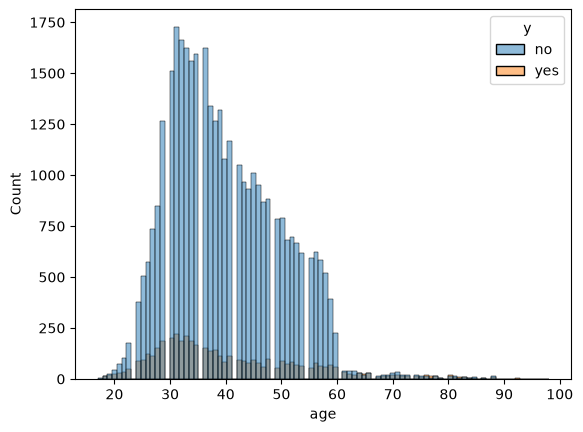

In [17]:
sns.histplot(df, x="age", hue="y")

📝: The target is `y` - did the client subscribe to the term deposit after the campaign call.

📝: About one client in nine says yes...

Answering "no" to every single client already scores whatever you see printed above, subtracted from one, so the model looks good by doing nothing.
The question that actually matters is of the clients we decide to call, how many subscribe?

Calling costs money, and that number is precision.
Its mirror image is recall, the share of subscribers we managed to reach, and the two move in opposite directions when you change
the probability above which you call someone. `predict_proba` gives the probability; 0.5 is just a default, not a
decision anybody made.

So six numbers are reported now, further down. They took an afternoon and they were worth it.

📝: `duration` is off limits - nobody knows the call duration before the call ends.
I wrapped that up with the target mapping so I stop forgetting one of the two.

In [18]:
features, labels = to_features_and_labels(df)
print(f"positive rate: {labels.mean():.3f}")
print(f"{features.shape[1]} features left once y and duration are out")

positive rate: 0.113
19 features left once y and duration are out


In [19]:
dataset = get_dataset(
    df,
    test_size=settings.training.test_size,
    val_size=settings.training.val_size,
    seed=settings.training.seed,
)
print(f"train {len(dataset.train_x)} | val {len(dataset.val_x)} | test {len(dataset.test_x)}")

train 24714 | val 8237 | test 8237


# Training

📝: One thing to know before reading the pipeline: nobody in this dataset was ever called in January or
February.

A `OneHotEncoder` builds its columns from the values it sees while fitting, so left alone it would give the model
no January input at all, and the campaign starts again in the winter. Same story for the days of the week, on a
smaller scale. Those two columns have a list of values that is known in advance and has nothing to do with which
rows we happened to collect, so I pass the list in rather than let the encoder discover it. The other categorical
columns really do have to be learned from the data, so they are encoded separately.

In [20]:
df.month.value_counts()

month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64

📝: One `Pipeline` holding both the preprocessing and the classifier, so there is a single object to
save and a single object to call. The two steps are named `data_processor` and `model` - please keep those
names, whatever you do with this code afterwards.

In [21]:
model = build_model(settings.training)
forest = model.named_steps["model"]
print(f"pipeline: {forest.n_estimators} trees, max depth {forest.max_depth}, seed {forest.random_state}")

pipeline: 100 trees, max depth 8, seed 0


In [22]:
%%time
model = train(settings.training, dataset)
print(f"fitted on {len(dataset.train_x)} rows")

fitted on 24714 rows
CPU times: user 2.32 s, sys: 3.48 ms, total: 2.32 s
Wall time: 2.32 s


📝: The six numbers, in one function so I stop reporting a different set every week.

`positive_rate` is there so nobody reads `accuracy` without it. `precision` and `recall` describe one operating
point, the threshold. `roc_auc` and `average_precision` describe the ranking at every threshold at once, which is
what you compare between two runs when the threshold is still being argued about. On data this unbalanced,
`average_precision` (the area under the precision-recall curve) is the honest one: `roc_auc` stays flattering
because true negatives are plentiful and cost nothing.

In [23]:
val_metrics = get_model_evaluation_metrics(
    model, dataset.val_x, dataset.val_y, decision_threshold=settings.training.decision_threshold
)
print("--- validation ---")
for name, value in val_metrics.items():
    print(f"{name}: {value:.3f}")

--- validation ---
positive_rate: 0.113
accuracy: 0.901
precision: 0.696
recall: 0.212
roc_auc: 0.811
average_precision: 0.489


📝: And the curves, because a single threshold never tells you what the model is capable of.

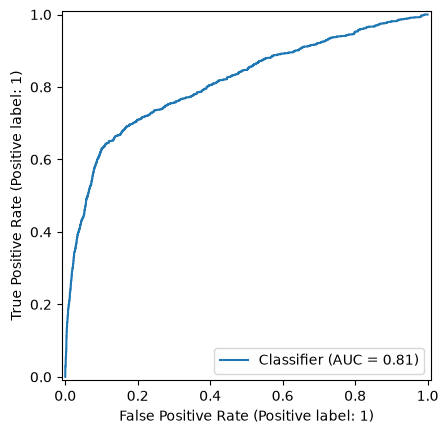

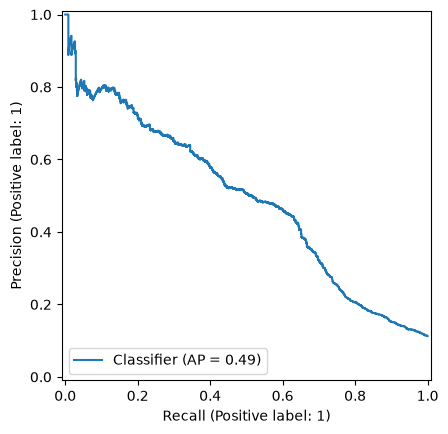

In [24]:
val_probabilities = model.predict_proba(dataset.val_x)[:, 1]
RocCurveDisplay.from_predictions(dataset.val_y, val_probabilities)
PrecisionRecallDisplay.from_predictions(dataset.val_y, val_probabilities)

📝: The same thing as a table, since the curves are hard to read a number off. Every row is a different
answer to "how sure do we have to be before we spend a phone call on someone". The model is left at 0.5 because I
did not know who to ask, but that is a business decision and somebody should make it on purpose.

In [25]:
sweep = pd.DataFrame(
    [
        {"threshold": t, **get_model_evaluation_metrics(model, dataset.val_x, dataset.val_y, decision_threshold=t)}
        for t in [0.2, 0.3, 0.4, 0.5, 0.6]
    ]
)
sweep[["threshold", "accuracy", "precision", "recall"]].round(3)

,threshold,accuracy,precision,recall
0,0.2,0.875,0.460,0.601
1,0.3,0.886,0.496,0.522
2,0.4,0.904,0.640,0.332
3,0.5,0.901,0.696,0.212
4,0.6,0.899,0.757,0.154


In [28]:
test_metrics = get_model_evaluation_metrics(
    model, dataset.test_x, dataset.test_y, decision_threshold=settings.training.decision_threshold
)
print("--- test ---")
for name, value in test_metrics.items():
    print(f"{name}: {value:.3f}")

--- test ---
positive_rate: 0.113
accuracy: 0.899
precision: 0.679
recall: 0.192
roc_auc: 0.797
average_precision: 0.455


📝: Those are decent numbers. Time to save the model.

In [29]:
artifact_path = notebook_dir / "best_model.pkl"
persist_model(model, artifact_path)
print(f"saved {artifact_path.name} ({artifact_path.stat().st_size / 1e6:.1f} MB)")

saved best_model.pkl (2.4 MB)


📝: Works on my machine 🎉 The API part is somebody else's problem.

Everything this notebook did is printed above, so scroll up if you need to know what ran. I kept meaning to look
into the `logging` module, but `print` never let me down.